In [1]:
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')

gat_config = GATConfig.gpt_size("small", [BOS_TOKEN_ID+1, 128])
model = GAT(gat_config)

# ---- load ckpt ----
def local_load_ckpt(model, ckpt_path):
    """load compiled ckpt locally"""
    model_ckpt = torch.load(ckpt_path, map_location="cpu")['model']
    clean_state_dict = {k.replace("_orig_mod.", ""): v for k, v in model_ckpt.items()}
    model.load_state_dict(clean_state_dict)
    return model

ckpt_path = "ckpt/ts-k4-v128.pt"
model = local_load_ckpt(model, ckpt_path)
K = 4


from src.model import GPT_base, GPTConfig

gpt_config = GPTConfig.gpt_size("small", BOS_TOKEN_ID + 1)
base_model = GPT_base(gpt_config)
base_ckpt_path = "ckpt/gpt2-small-ts.pt"
base_model = local_load_ckpt(base_model, base_ckpt_path)

# model = model.to("cuda")
# model = torch.compile(model)

In [6]:
from data.tinystory_local import TinyStoriesDataLoader, TinyStoriesDataLoader_v2, collect_rollout_statistics, AbstractionStatistics
from data.tinystory_local import visualize_dynamics
import tiktoken 

# TinyStories Dataset + GPT2 tokenizer
# -------------------------------------
num_stories = 100
max_len = 128
doc_len = max_len  + (max_len - 1) // K # <-- doc len contains abstract tokens
pad_shift = 2
loader = TinyStoriesDataLoader(num_stories=num_stories, max_len=max_len, chunk_size=K, device='cpu', split="validation", pad_shift=pad_shift)

batch_size = 8
memory_span = 1792
attn_blocksize = 1792
max_iterations = 2

# ---- stat collection ---
abs_stats = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

# --- tokenizer --- 
enc = tiktoken.get_encoding("gpt2")
eot = enc._special_tokens['<|endoftext|>']

Loading 100 stories from TinyStories validation...
Loaded 100 stories, 12554 tokens total, 0.05 MB
Collected 2707 unique 4-chunks


In [81]:
import math 
-math.log(0.5)

0.6931471805599453

In [3]:
# (I). Generate with SoRL trained on TinyStories Dataset
# -------------------------------------------------
from sorl.neo_utils import generate
from data.tinystory_local import visualize_interleaved_alignment    

min_temperature = 0.0
tokens, doc_ids = loader.get_batch(1)

# idx = tokens[:, :15].clone()
idx = torch.tensor(enc.encode("Chrismas is coming soon, ")).unsqueeze(0)

img_frames = []
for i in range(120): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=torch.tensor(min_temperature))
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    img = visualize_interleaved_alignment(idx, model, enc, K=K, max_chunks=8)
    img_frames.append(img)

# ---- save to gif ----
if len(img_frames) > 0:
    img_frames[0].save(
        'tiny-tiny-stories-generation.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=400,  # milliseconds sper frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

Saved GIF with 120 frames


In [ ]:
from huggingface_hub import HfApi

# ---- upload ckpt to huggingface ----

api = HfApi()
# api.create_repo(repo_id="Ksgk-fy/sorl", repo_type="model", private=False)

# api.upload_file(
#     path_or_fileobj="ckpt/ts-k4-v128.pt",
#     path_in_repo="ts-k4-v128.pt",
#     repo_id="Ksgk-fy/sorl",
#     repo_type="model"
# )

# api.upload_file(
#     path_or_fileobj="ckpt/gpt2-small-ts.pt",
#     path_in_repo="gpt2-small-ts.pt",
#     repo_id="Ksgk-fy/sorl",
#     repo_type="model"
# )

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Ksgk-fy/sorl/commit/8347005f4ca8e424acb10747c15863e00eb1aaf2', commit_message='Upload gpt2-small-ts.pt with huggingface_hub', commit_description='', oid='8347005f4ca8e424acb10747c15863e00eb1aaf2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Ksgk-fy/sorl', endpoint='https://huggingface.co', repo_type='model', repo_id='Ksgk-fy/sorl'), pr_revision=None, pr_num=None)

In [10]:
from sorl.forget import compute_abs_stats_v4
from tqdm import tqdm
from collections import defaultdict

n = 5
temperature = torch.tensor([0.0] + [5.0] * (n - 1))
batch_size = 2

# Collect all stats
all_stats = defaultdict(list)

with tqdm(total=len(loader.stories), desc="Processing batches") as pbar:
    for i in range(0, len(loader.stories), batch_size):
        batch_indices = torch.arange(i, min(i + batch_size, len(loader.stories)))
        tokens, doc_ids = loader.get_specific(batch_indices)

        stat_dict = compute_abs_stats_v4(
            tokens, model, base_model, n=n, K=K, max_iterations=max_iterations,
            memory_span=memory_span, attn_blocksize=attn_blocksize,
            temperature=temperature, truncate_seq_len=False, pad_token=loader.pad_token
        )

        for key, val in stat_dict.items():
            all_stats[key].append(val.item() if hasattr(val, 'item') else val)

        pbar.update(len(batch_indices))
        break

# Print averages
for key, vals in all_stats.items():
    print(f"{key}: {sum(vals) / len(vals):.6f}")

Processing batches:   2%|▏         | 2/100 [00:02<01:41,  1.04s/it]

id_base_traj_loss: 1.316271
id_greedy_traj_loss: 1.227240
id_greedy_info_gain: 0.089031
id_search_info_gain: 0.091862
id_greedy_adv: 0.306241
alien_base_traj_loss: 19.114380
alien_greedy_traj_loss: 22.920513
alien_greedy_info_gain: -3.806132
alien_search_info_gain: -3.806132
alien_greedy_adv: 0.021730


In [47]:
temperature = torch.tensor([0.0] + [0.5] * (n - 1))

In [66]:
from sorl.forget import * 
truncate_seq_len = False
pad_token = loader.pad_token

search_data, search_ppt, abs_logits = sorl_rollout_v3(tokens, model, n=n, K=K, 
                                                            max_iterations=max_iterations,
                                                        memory_span=memory_span,
                                                        attn_blocksize=attn_blocksize,
                                                        temperature=temperature,
                                                        truncate_seq_len=truncate_seq_len)
search_ppt = search_ppt.reshape(search_data.shape[0], -1)

# --- greedy & random rollout ppt ---
cond_traj_mask = (search_data[0, 1:] < model.vocab_sizes[0])
greedy_traj_ppt = search_ppt[0][cond_traj_mask]
random_traj_ppt = search_ppt[1:].mean(dim=0)[cond_traj_mask]


# --- base traj loss ---
base_traj_ppt = base_model.forward(tokens[:, :-1].long(), tokens[:, 1:].long(), attn_blocksize)
base_traj_mask = (tokens[:, 1:] != BOS_TOKEN_ID).float()
base_traj_loss = (base_traj_ppt * base_traj_mask[0]).sum() / base_traj_mask.sum().clamp(min=1)

base_pad_mask = (tokens[:, 1:] == pad_token).float()
search_pad_mask = (search_data[:, 1:] == pad_token).float()

# --- search (per-doc-best rollout) info gain ---
levels = (search_data >= model.vocab_sizes[0]).long()
best_data, best_ppt, _, _ = select_best_info_gain(tokens, base_traj_ppt * base_pad_mask, search_data, search_ppt * search_pad_mask, levels)
best_traj_ppt = best_ppt[cond_traj_mask]

# --- information gain, search advantage (relative & absolute) ---
greedy_adv = ((random_traj_ppt - greedy_traj_ppt) / (random_traj_ppt + 1e-8))
greedy_abs_adv = (random_traj_ppt - greedy_traj_ppt)
search_adv = ((random_traj_ppt - best_traj_ppt) / (random_traj_ppt + 1e-8))
search_abs_adv = (random_traj_ppt - best_traj_ppt)
greedy_info_gain = (base_traj_ppt - greedy_traj_ppt)
search_info_gain = (base_traj_ppt - best_traj_ppt)

greedy_traj_loss = greedy_traj_ppt.mean()
search_traj_loss = best_traj_ppt.mean()

# --- alien mask ---
pad_mask = (tokens[:, 1:] == pad_token).float()
alien_greedy_adv = ((greedy_adv * pad_mask).sum() / (pad_mask.sum() + 1e-8)) 
alien_search_adv = ((search_adv * pad_mask).sum() / pad_mask.sum()) 
alien_greedy_info_gain = ((greedy_info_gain * pad_mask).sum() / (pad_mask.sum() + 1e-8)) 
alien_search_info_gain = ((search_info_gain * pad_mask).sum() / (pad_mask.sum() + 1e-8)) 
id_greedy_info_gain = ((greedy_info_gain * (1 - pad_mask)).sum() / (1 - pad_mask).sum()) 
id_search_info_gain = ((search_info_gain * (1 - pad_mask)).sum() / (1 - pad_mask).sum()) 

alien_greedy_traj_loss = ((greedy_traj_ppt * pad_mask).sum() / (pad_mask.sum() + 1e-8)) 
id_greedy_traj_loss = ((greedy_traj_ppt * (1 - pad_mask)).sum() / (1 - pad_mask).sum()) 
alien_base_traj_loss = ((base_traj_ppt * pad_mask).sum() / (pad_mask.sum() + 1e-8)) 
id_base_traj_loss = ((base_traj_ppt * (1 - pad_mask)).sum() / (1 - pad_mask).sum()) 


In [75]:
best_traj_ppt - greedy_traj_ppt

tensor([ 0.0000e+00, -8.5547e+00, -1.0511e+00, -6.3447e+00, -4.0762e+00,
        -6.6989e+00, -3.1357e+00, -1.9708e+00, -5.5764e+00, -1.9197e-01,
        -1.8553e-03, -2.9120e-01, -4.6000e-01, -1.4928e+01, -2.0530e+00,
        -2.1544e+00, -2.0353e-02, -2.1191e-02, -1.2647e-01, -5.2255e+00,
        -7.9787e-01, -2.7575e+00, -2.4376e-01, -3.9703e-01, -6.0810e-01,
        -7.9533e-03, -4.5204e+00, -2.0061e-04, -2.4795e-05, -4.5142e-01,
        -7.2472e-03, -6.3967e-02, -6.2216e-03, -5.8654e-01, -5.2500e-01,
        -3.4300e+00, -1.1903e-01, -8.7686e-02, -6.9529e-02, -1.0875e+00,
        -8.5173e-01, -2.0629e-02, -8.2556e+00, -2.2993e+00, -1.5595e+00,
        -1.9008e+00, -3.3925e-02, -1.2833e-01, -6.8830e+00, -1.4157e+00,
        -1.0669e-03, -5.1702e+00, -2.4016e+00, -2.4224e-02, -5.6460e-01,
        -4.3693e+00, -1.2231e-01, -3.1007e+00, -2.1288e+00, -1.8694e+00,
        -1.9075e+00, -7.6155e-02, -6.0448e-01, -1.0722e+00, -1.5375e+00,
        -1.5396e+00, -5.1313e-01, -2.9813e-02, -3.9

In [72]:
(best_traj_ppt * pad_mask).sum() / (pad_mask.sum() + 1e-8)

tensor(22.9205)

In [73]:
(greedy_traj_ppt * pad_mask).sum() / (pad_mask.sum() + 1e-8)

tensor(22.9205)

In [59]:
alien_search_adv, alien_greedy_adv

(tensor(1.), tensor(0.0117))

In [60]:
(greedy_traj_ppt * pad_mask).sum() / (pad_mask.sum() + 1e-8)

tensor(22.9205)

In [61]:
(best_traj_ppt * pad_mask).sum() / (pad_mask.sum() + 1e-8)

tensor(0.)

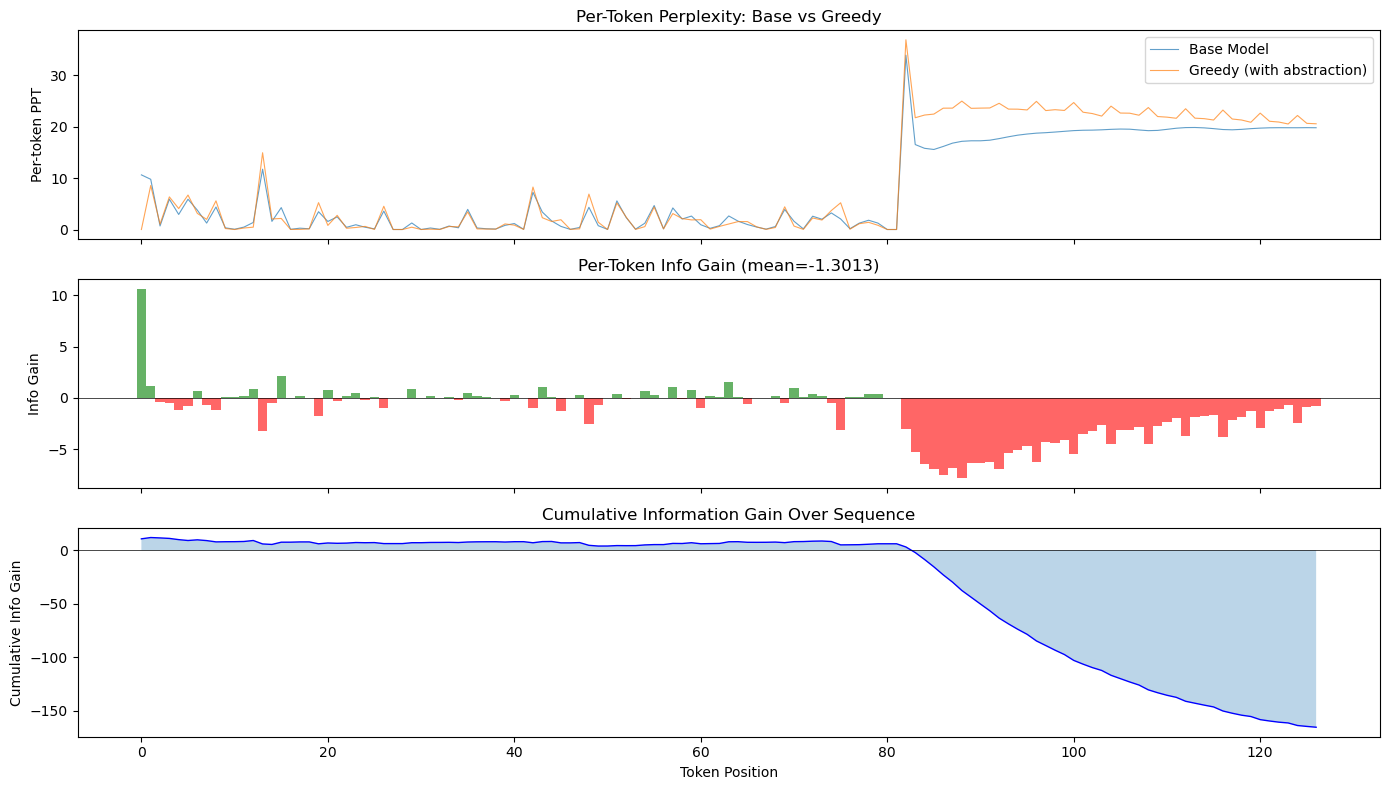

Mean base PPT: 8.0086 | Mean greedy PPT: 9.3098 | Mean info gain: -1.3013


In [8]:
from sorl.forget import visualize_info_gain

# Usage:
batch_indices = torch.arange(0, 1)
tokens, doc_ids = loader.get_specific(batch_indices)

res_dict = visualize_info_gain(tokens, model, base_model, K, max_iterations, memory_span, attn_blocksize)

In [ ]:
# pad shift = 1 | [PAD] = 50255 | ' gazed'
# base traj loss: 1.0408923625946045
# cond traj loss (greedy): 0.9784106612205505
# cond traj loss (search): 0.9784106612205505
# greedy relative adv: 0.34876561164855957
# search relative adv: 0.34876561164855957
# greedy absolute adv: 0.18474332988262177
# search absolute adv: 0.18474332988262177
# greedy info gain: 0.13361677527427673
# search info gain: 0.13361677527427673

# pad shift = 2 | [PAD] = 50254 | ' informants'
# base traj loss: 1.1698700189590454
# cond traj loss (greedy): 1.2397736310958862
# cond traj loss (search): 1.2396743297576904
# greedy relative adv: 0.3486286997795105
# search relative adv: 0.34838542342185974
# greedy absolute adv: 0.1853206306695938
# search absolute adv: 0.18541988730430603
# greedy info gain: 0.0008413493633270264
# search info gain: 0.0009406125755049288
# nope, given the alien token suffix with a different idx, the benefit of SoRL is gone
# so it's rather about the special pad token idx that gives SoRL its advantage

# pad shift = 3 | [PAD] = 50253 | ' Collider'
# base traj loss: 1.2469276189804077
# cond traj loss (greedy): 1.208359956741333
# cond traj loss (search): 1.208359956741333
# greedy relative adv: 0.3492974042892456
# search relative adv: 0.3492974042892456
# greedy absolute adv: 0.18968331813812256
# search absolute adv: 0.18968331813812256
# greedy info gain: 0.10883079469203949
# search info gain: 0.10883079469203949

# pad shift = 4 | [PAD] = 50252 | ' regress'
# base traj loss: 1.2160274982452393
# cond traj loss (greedy): 1.1208767890930176
# cond traj loss (search): 1.1208767890930176
# greedy relative adv: 0.34851834177970886
# search relative adv: 0.34851834177970886
# greedy absolute adv: 0.1844305396080017
# search absolute adv: 0.1844305396080017
# greedy info gain: 0.1669972538948059
# search info gain: 0.1669972538948059

# pad shift = 5 | [PAD] = 50251 | 'ominated'
# base traj loss: 1.2109959125518799
# cond traj loss (greedy): 1.116715669631958
# cond traj loss (search): 1.116715669631958
# greedy relative adv: 0.34858277440071106
# search relative adv: 0.34858277440071106
# greedy absolute adv: 0.18613815307617188
# search absolute adv: 0.18613815307617188
# greedy info gain: 0.16398979723453522
# search info gain: 0.16398979723453522

# pad shift = 6 | [PAD] = 50250 | ' amplification'
# base traj loss: 1.1891472339630127
# cond traj loss (greedy): 1.2156203985214233
# cond traj loss (search): 1.210188627243042
# greedy relative adv: 0.3479643166065216
# search relative adv: 0.3451973795890808
# greedy absolute adv: 0.1694093942642212
# search absolute adv: 0.17484118044376373
# greedy info gain: 0.04343022033572197
# search info gain: 0.04886201024055481

# [PAD] = 62 | '_'
# base traj loss: 1.1573103666305542
# cond traj loss (greedy): 1.1418373584747314
# cond traj loss (search): 1.1232270002365112
# greedy relative adv: 0.3473825454711914
# search relative adv: 0.3297266662120819
# greedy absolute adv: 0.1501348912715912
# search absolute adv: 0.1687452495098114
# greedy info gain: 0.08608052134513855
# search info gain: 0.10469089448451996

# [PAD] = 50006 | '�'


torch.Size([1, 324])

In [27]:
enc.decode([250])
# enc.encode("_")

'�'

In [30]:
BOS_TOKEN_ID - 250

50006

In [9]:
# 

# Remark #1. 
# - in 'compute_abs_stats', info gain is computed per doc not per-token
# - in 'loss_fn', info gain is computed between 'average per-token' base_traj and 'average per-token' cond_traj in a 'misaligned way' (due to suffix truncation)
# - during training, we got (a). prefix truncation for both base traj & cond traj (b). suffix truncation for cond traj (so that len(cond traj) = len(base traj))
# - these two factors confound with the metric, and lead to different with above metric

# Remark #2. 
# - did some fixes on the 'compute_abs_stats' function, it's easy to mess up 'search' & 'greedy' with 
#   'random rollouts', especially, search is used to represent random rollout aswell as best rolout
#   obtained via search


tensor([1.1009, 1.5971])

In [17]:
compute_abs_stats_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                                                            truncate_seq_len=False)

(tensor(1.5995),
 tensor([0.0762, 0.0214], grad_fn=<DivBackward0>),
 tensor(0.0432, grad_fn=<DivBackward0>),
 tensor(0.1001),
 tensor(0., grad_fn=<DivBackward0>))

In [ ]:
from sorl.forget import * 
truncate_seq_len = False



In [ ]:
from sorl.forget import collect_forget_data, plot_normalized_correlation_lines, train_forget_vec
from tqdm import tqdm as tqdm

# ---- Memory Interference Experiment ---

abs_stats = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

abs_stats_post = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

# ---- Compute 'Forget Matrix' --- 
forget_mat = torch.zeros(num_stories, num_stories, device=model.device)
num_steps = 40
for train_idx in tqdm(range(num_stories)): 
    forget_vec = train_forget_vec(train_idx, loader, model, abs_stats, abs_stats_post, optimizer, num_steps,
                                max_iterations, memory_span, attn_blocksize, temperature, K, r_min, reward_mode, loss_fn, alpha_abs, alpha_soft_zipf, alpha_topo,
                                ckpt_path="sorl_tinystories.pt")
    forget_mat[train_idx] = forget_vec 

# torch.save(forget_mat, "forget_mat.pt") # save it just in case

# # ---- Visualize 'Forget Matrix' --- 
# correlation_data, ham_corrs = collect_forget_data(forget_mat, abs_stats)

# plot_normalized_correlation_lines(
#     correlation_data, 
#     ham_corrs,
#     xlabel="Abstraction Edit Distance", 
#     ylabel="Forgetting (Δ Perplexity)",
#     title="Distant Abstractions → Less Forgetting (TinyStories)"
# )

In [ ]:
# Exp #1. 
# 'self-organization' of abstraction representation --> will SoRL tries to pull mixing memory apart? 
# Exp #2. 
# setting up tiny memory dataset training pipeline 
# Question #1. 
# What if we use all-rollout SoRL with utility advantage + KL reg terms? 


In [ ]:
from data.tinystory_local import *
from sklearn.decomposition import PCA

cs_sim = abs_stats.compute_cross_doc_logit_sim()
# cs_sim = abs_stats.compute_cross_doc_hamming()
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(cs_sim.cpu().numpy())

# Now use in 3D visualization
train_idx = 0
perplexity = forget_mat[train_idx]
img = visualize_forget_terrain(coords_2d, perplexity, trained_idx=train_idx, step=step)
# img = visualize_perplexity_terrain(coords_2d, perplexity, trained_idx=train_idx, step=step)

In [4]:
# Hypothesis #2. 
# ------------------------------------------------------------
# forget(i | j) is proportional to 1 / d(a_i, a_j)
# dis-similar concept is less likely to be overwritten by each other
# similar concept is more likely to be overwritten by each other
# the emerged abstraction system from SoRL can describe such similarity via d(a_i, a_j)
# ------------------------------------------------------------

# Experiment 
# (a). Train till emergence
# (b). Train with specific order. 
# (c). Record 'forgetting matrix'

import numpy as np
np.array(record['topo_loss'][:5]).mean(), np.array(record['topo_loss'][-5:]).mean()

(-0.7774280548095703, -0.7865824460983276)

In [4]:
if len(img_frames) > 0:
    img_frames[0].save(
        'tinystories_dynamics (select-best per abs SoRL + 1.0 topo reg + 1.0 bigram zipf reg + utility reward scaling.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=400,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

Saved GIF with 200 frames


In [ ]:
# Generate with SoRL trained on TinyStories Dataset
# -------------------------------------------------
from sorl.neo_utils import generate
from data.tinystory_local import visualize_interleaved_alignment    

min_temperature = 0.0
tokens, doc_ids = loader.get_batch(1)

idx = tokens[:, :15].clone()

img_frames = []
for i in range(30): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=torch.tensor(min_temperature))
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    img = visualize_interleaved_alignment(idx, model, enc, K=K, max_chunks=8)
    img_frames.append(img)

# ---- save to gif ----
if len(img_frames) > 0:
    img_frames[0].save(
        'tiny-tiny-stories-generation.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=400,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

In [ ]:
# Request #1. 
# -> Full scale experiment on TinyStories & FineWeb

In [ ]:
# marg cond w = 1.0 
# traj_loss: 0.85 | abs_loss: 0.04 | search adv: 21.01% | vocab util: 93.75%  | marg_ent: 2.67 | cond_ent: 0.05 | avg cos sim: 0.44

# soft bigram zipf kl w = 1.0 
# traj_loss: 0.89 | abs_loss: 0.53 | search adv: 25.84% | vocab util: 68.75%  | kl_soft_zipf: 0.24 | avg cos sim: 0.47
# -> visually I observe much less 'repetitions'

# soft bigram zipf kl w = 1.0 & utility reward scaling r = max(p(s|a)/p(s), 1.0)
# traj_loss: 0.79 | abs_loss: 0.40 | search adv: 30.13% | vocab util: 62.50%  | kl_soft_zipf: 0.17 | avg cos sim: 0.44 | topo sim: 0.77 

# soft bigram zip w=1.0 & utility reward scaling & topo reg w=1.0
# traj loss: 1.50 | search adv: 20% | avg cos sim: 0.24 | topo sim: 0.53
# => degrades utility, no go

